In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from fastai.vision import *
import torch
import torch.nn as nn
from torchvision.models import resnet50

In [2]:
path = 'Downloads/Skin_cancer_dataset'
csv_file = 'Downloads/Skin_cancer_dataset/HAM10000_metadata.csv'

In [3]:
df = pd.read_csv(csv_file).set_index('image_id')
df

,lesion_id,dx,dx_type,age,sex,localization,dataset
image_id,,,,,,,
ISIC_0027419,HAM_0000118,bkl,histo,80.0,male,scalp,vidir_modern
ISIC_0025030,HAM_0000118,bkl,histo,80.0,male,scalp,vidir_modern
ISIC_0026769,HAM_0002730,bkl,histo,80.0,male,scalp,vidir_modern
ISIC_0025661,HAM_0002730,bkl,histo,80.0,male,scalp,vidir_modern
ISIC_0031633,HAM_0001466,bkl,histo,75.0,male,ear,vidir_modern
...,...,...,...,...,...,...,...
ISIC_0033084,HAM_0002867,akiec,histo,40.0,male,abdomen,vidir_modern
ISIC_0033550,HAM_0002867,akiec,histo,40.0,male,abdomen,vidir_modern
ISIC_0033536,HAM_0002867,akiec,histo,40.0,male,abdomen,vidir_modern


In [4]:
lesion_type_dict = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis ',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}

In [5]:
df.dx=df.dx.astype('category',copy=True)
df['labels']=df.dx.cat.codes
df['lesion']= df.dx.map(lesion_type_dict)
df

,lesion_id,dx,dx_type,age,sex,localization,dataset,labels,lesion
image_id,,,,,,,,,
ISIC_0027419,HAM_0000118,bkl,histo,80.0,male,scalp,vidir_modern,2,Benign keratosis
ISIC_0025030,HAM_0000118,bkl,histo,80.0,male,scalp,vidir_modern,2,Benign keratosis
ISIC_0026769,HAM_0002730,bkl,histo,80.0,male,scalp,vidir_modern,2,Benign keratosis
ISIC_0025661,HAM_0002730,bkl,histo,80.0,male,scalp,vidir_modern,2,Benign keratosis
ISIC_0031633,HAM_0001466,bkl,histo,75.0,male,ear,vidir_modern,2,Benign keratosis
...,...,...,...,...,...,...,...,...,...
ISIC_0033084,HAM_0002867,akiec,histo,40.0,male,abdomen,vidir_modern,0,Actinic keratoses
ISIC_0033550,HAM_0002867,akiec,histo,40.0,male,abdomen,vidir_modern,0,Actinic keratoses
ISIC_0033536,HAM_0002867,akiec,histo,40.0,male,abdomen,vidir_modern,0,Actinic keratoses


In [6]:
print(df.lesion.value_counts())

lesion
Melanocytic nevi        6705
Melanoma                1113
Benign keratosis        1099
Basal cell carcinoma     514
Actinic keratoses        327
Vascular lesions         142
Dermatofibroma           115
Name: count, dtype: int64


<Axes: xlabel='count', ylabel='lesion'>

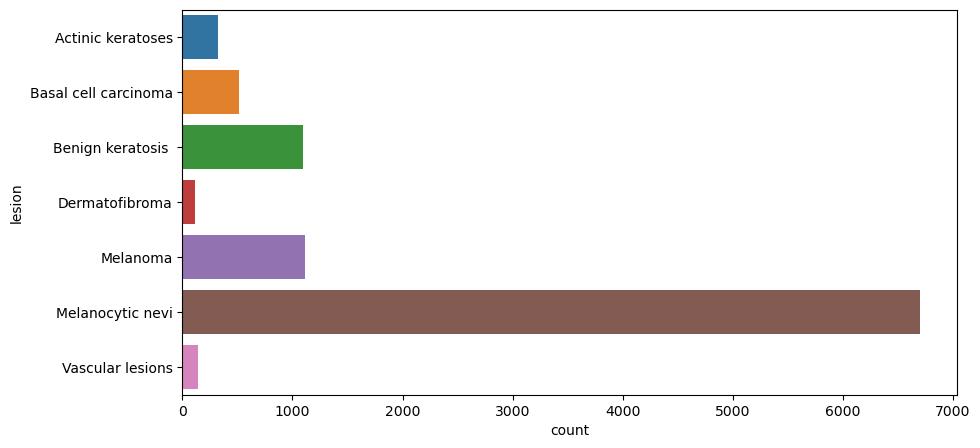

In [7]:
fig, ax1 = plt.subplots(1, 1, figsize = (10, 5))
sns.countplot(y='lesion',data=df, hue="lesion",ax=ax1)

In [8]:
class CustomImageItemList(ImageList):
    def custom_label(self, df, **kwargs) -> 'LabelList':
        file_names = [p.stem for p in self.items]
        get_labels = lambda x: df.loc[x, 'lesion']
        labels = get_labels(file_names)
        y = CategoryList(items=labels)
        res = self._label_list(x=self, y=y)
        return res

In [9]:
import torch
import fastai.vision.transform

# Create the bridge to the modern PyTorch function
def patched_solve(B, A):
    return torch.linalg.solve(A, B), None

# Inject it directly into fastai's internal transform module
fastai.vision.transform._solve_func = patched_solve

In [10]:
def get_data(bs, size):
    train_ds = (CustomImageItemList.from_folder('Downloads/Skin_cancer_dataset/HAM10000_images_part_1', extensions='.jpg')
                    .random_split_by_pct(0.15)
                    .custom_label(df)
                    .transform(tfms=get_transforms(flip_vert=True),size=size)
                    .databunch(num_workers=0, bs=bs)
                    .normalize(imagenet_stats))
    return train_ds

In [11]:
data=get_data(16,224)
data

C:\Users\Akshat Bhatt\anaconda3\Lib\site-packages\fastai\data_block.py:217: UserWarning: `random_split_by_pct` is deprecated, please use `split_by_rand_pct`.
  warn("`random_split_by_pct` is deprecated, please use `split_by_rand_pct`.")


ImageDataBunch;

Train: LabelList (4250 items)
x: CustomImageItemList
Image (3, 224, 224),Image (3, 224, 224),Image (3, 224, 224),Image (3, 224, 224),Image (3, 224, 224)
y: CategoryList
Melanocytic nevi,Melanocytic nevi,Melanoma,Melanoma,Melanoma
Path: Downloads\Skin_cancer_dataset\HAM10000_images_part_1;

Valid: LabelList (750 items)
x: CustomImageItemList
Image (3, 224, 224),Image (3, 224, 224),Image (3, 224, 224),Image (3, 224, 224),Image (3, 224, 224)
y: CategoryList
Melanocytic nevi,Basal cell carcinoma,Benign keratosis ,Melanocytic nevi,Melanocytic nevi
Path: Downloads\Skin_cancer_dataset\HAM10000_images_part_1;

Test: None

In [12]:
data.classes=list(np.unique(df.lesion))  
data.c= len(np.unique(df.lesion))

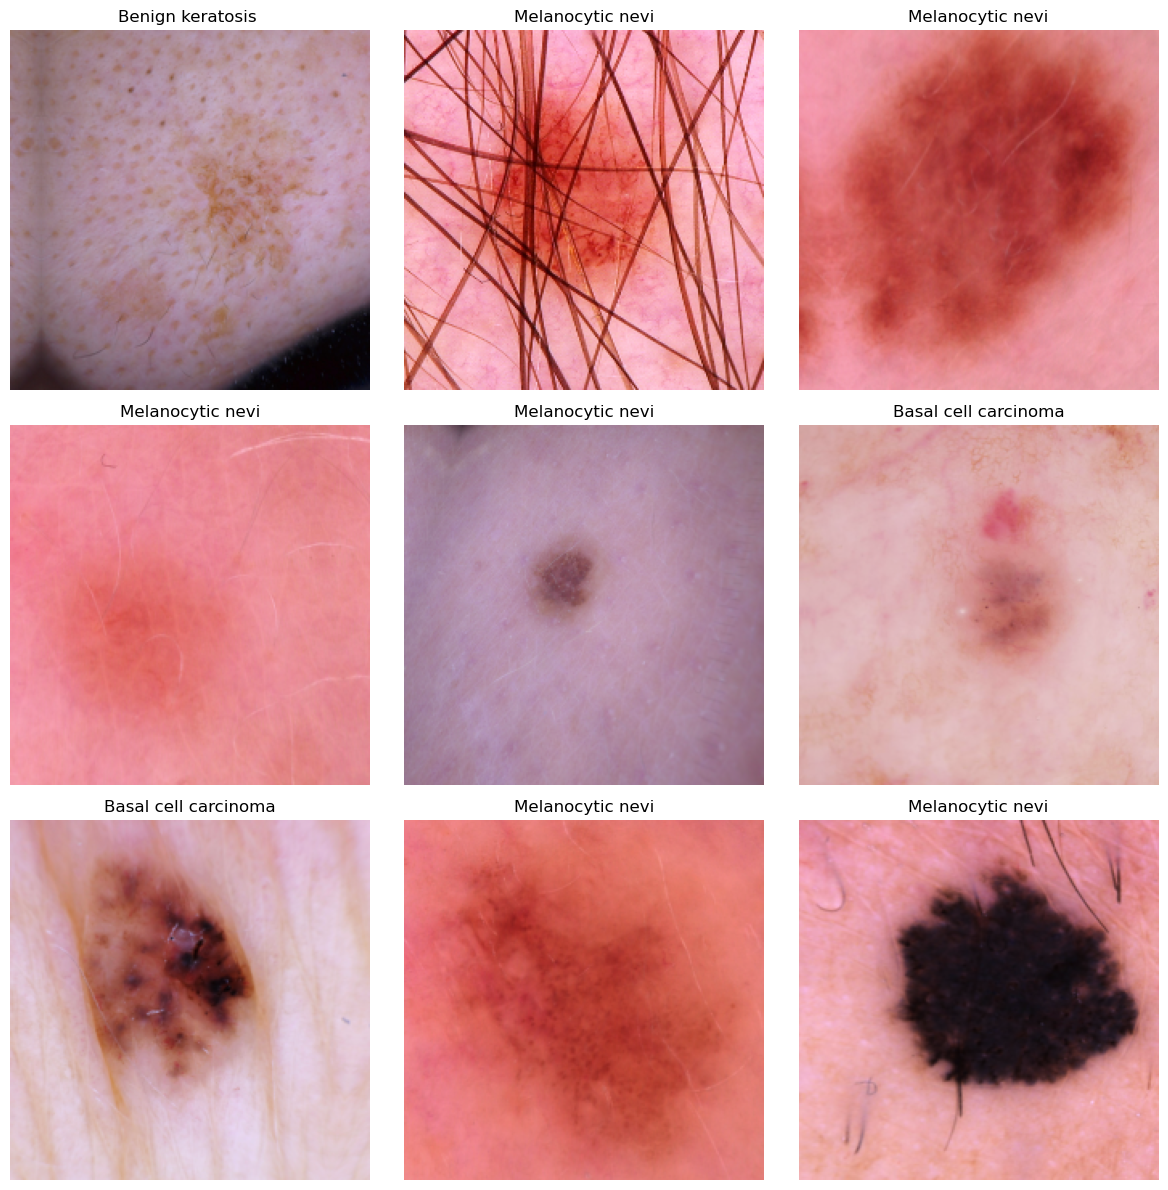

In [13]:
data.show_batch(rows=3)

C:\Users\Akshat Bhatt\anaconda3\Lib\site-packages\torchvision\models\_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(
C:\Users\Akshat Bhatt\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


epoch,train_loss,valid_loss,accuracy,time
0,1.368894,1.007543,0.720000,11:23
1,0.813019,0.733444,0.750667,11:26
2,0.694845,0.604493,0.788000,21:31
3,0.595990,0.570656,0.798667,11:27


epoch,train_loss,valid_loss,accuracy,time
0,0.664308,0.587757,0.793333,14:53
1,0.590656,0.544305,0.817333,14:52
2,0.520737,0.461548,0.833333,16:06
3,0.390458,0.431832,0.853333,14:56


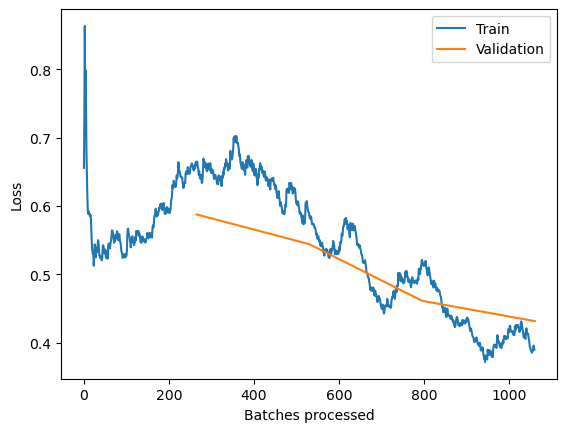

In [14]:
learn = cnn_learner(data, base_arch=resnet50, metrics=accuracy)
learn.fit_one_cycle(4)
learn.unfreeze()
learn.fit_one_cycle(4, max_lr=slice(1e-5, 1e-3))
learn.recorder.plot_losses()

In [15]:
learn.save('resnet50-ham10000-final')

In [16]:
learn.export('resnet50-ham10000.pkl')

In [17]:
import os
print(os.path.abspath(learn.path))

C:\Users\Akshat Bhatt\Downloads\Skin_cancer_dataset\HAM10000_images_part_1
